This notebook is created to test IMU-only state estimation.
In our setup, two motion models are implemented:
- Basic of kinematics 
- Velocity model.

By IMU-only state estimation, the accuracy of two motion models can be compared.

In [14]:
import os
import numpy as np
import sys
sys.path.append('/app/src')
from data_loader import DataLoader
from configs.configs import (
    SetupEnum, FilterEnum, NoiseTypeEnum, MeasurementDataEnum
)
from kalman_filters import ExtendedKalmanFilter
from kalman_filters import UnscentedKalmanFilter
from kalman_filters import EnsembleKalmanFilter
from kalman_filters import ParticleFilter, ResamplingAlgorithms
from kalman_filters import CubatureKalmanFilter


%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


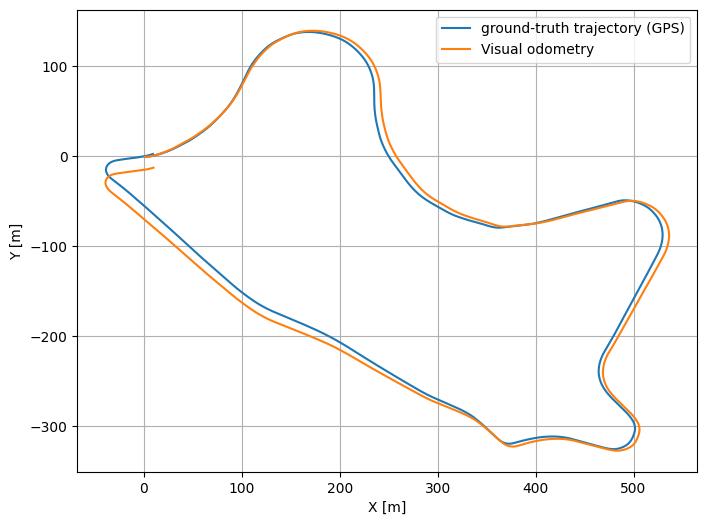

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'

# Dropping all measurement data results in IMU-only estimation
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=1.0, 
    gps_dropout_ratio=1.0,
    visualize_data=True
)

In [3]:
measurement_type=MeasurementDataEnum.DROPOUT
noise_type=NoiseTypeEnum.DEFAULT

# Basic of Kinematics

## EKF

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 12707.71it/s]


----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 292.372 m
Root Mean Squared Error: 343.554 m
Maximum Error: 838.412 m
---------------------------------------------------



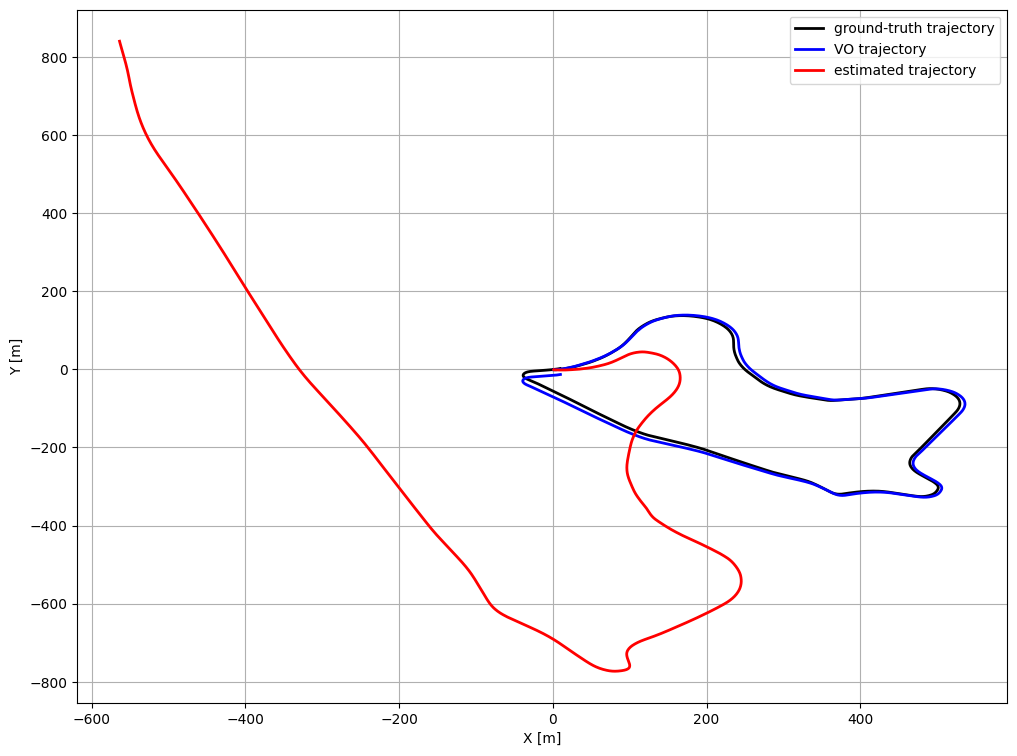

In [4]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.EKF,
    noise_type=noise_type)
ekf1_0 = ExtendedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1
)
ekf_error = ekf1_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True, 
    measurement_type=measurement_type
)

## UKF

[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 3894.32it/s]


----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3977.285 m
Root Mean Squared Error: 5384.894 m
Maximum Error: 13575.58 m
---------------------------------------------------



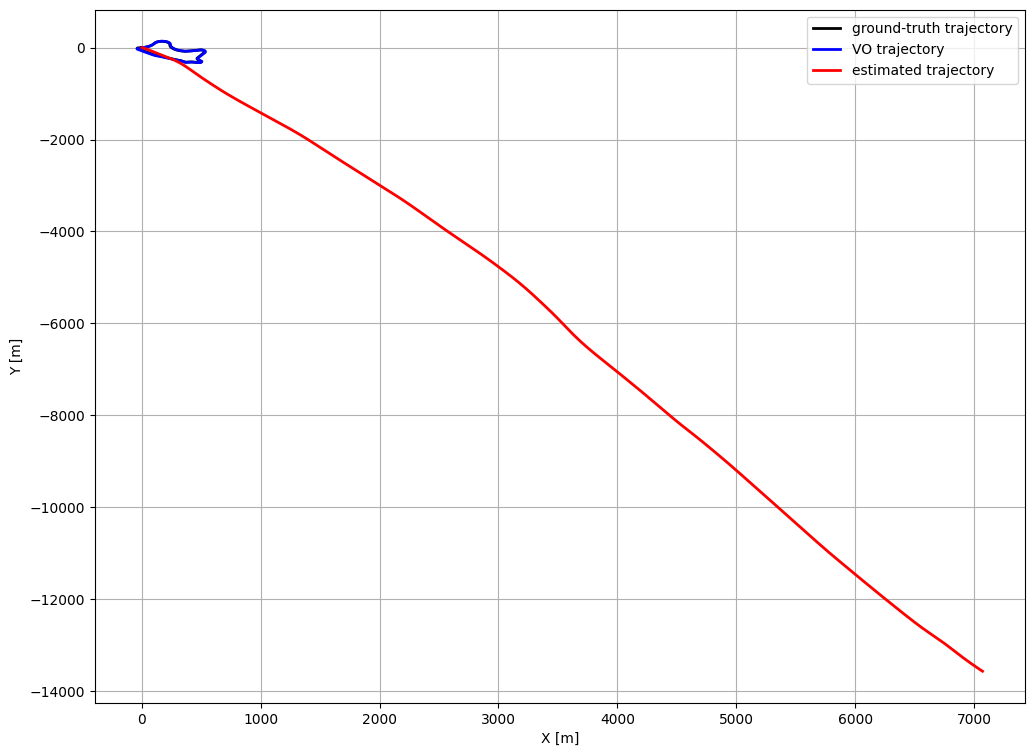

In [5]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.UKF,
    noise_type=noise_type
)

alpha_setup1_0 = 10.0
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

ukf1_0 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1
)
ukf_error = ukf1_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type
)

## PF

[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:13<00:00, 114.96it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 181.215 m
Root Mean Squared Error: 237.088 m
Maximum Error: 587.978 m
--------------------------------------------------



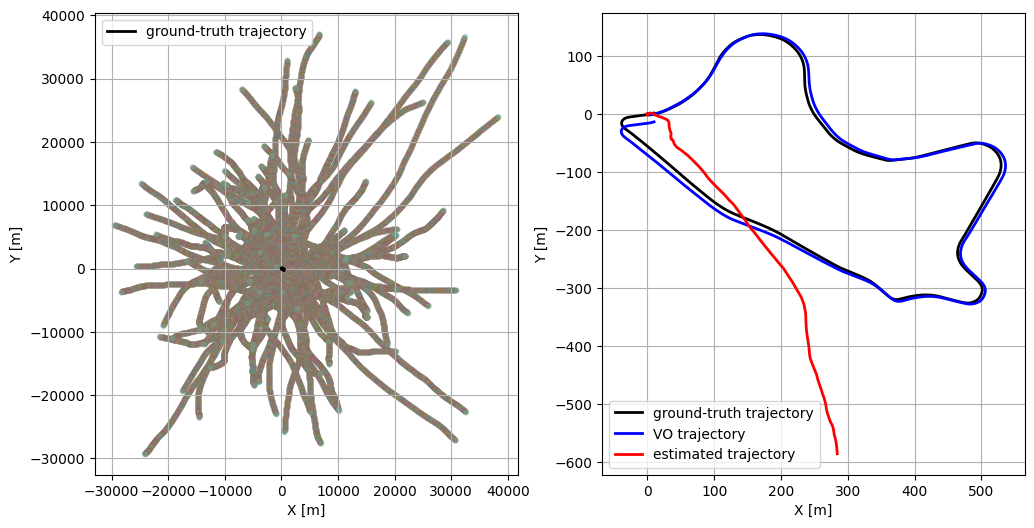

In [6]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.PF,
    noise_type=noise_type)

n_samples_setup1_0 = 1024
importance_resampling=True
resampling_algorithm_setup1_0 = ResamplingAlgorithms.STRATIFIED

pf1_0 = ParticleFilter(
    N=n_samples_setup1_0, 
    x_dim=x_setup1.shape[0], 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=resampling_algorithm_setup1_0)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf_error = pf1_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type,
    importance_resampling=importance_resampling
)

## EnKF

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:13<00:00, 117.60it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 389.634 m
Root Mean Squared Error: 492.586 m
Maximum Error: 888.574 m
----------------------------------------------------



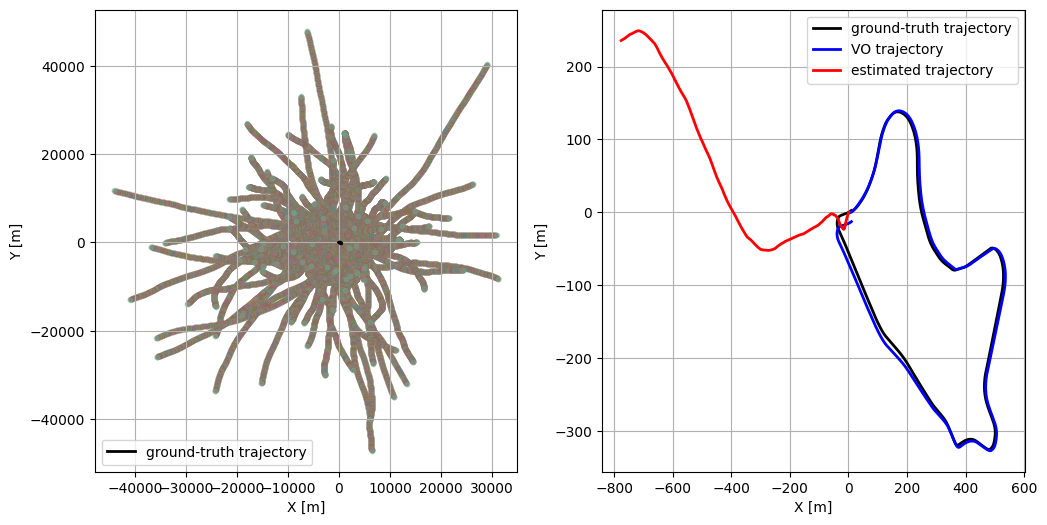

In [7]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.EnKF,
    noise_type=noise_type)

n_ensemble_setup1_0 = 1024

enkf1_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup1_0, 
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1
)
enkf_error = enkf1_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type
)

## CKF

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4148.59it/s]



----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 6339.572 m
Root Mean Squared Error: 9705.474 m
Maximum Error: 28862.721 m
---------------------------------------------------



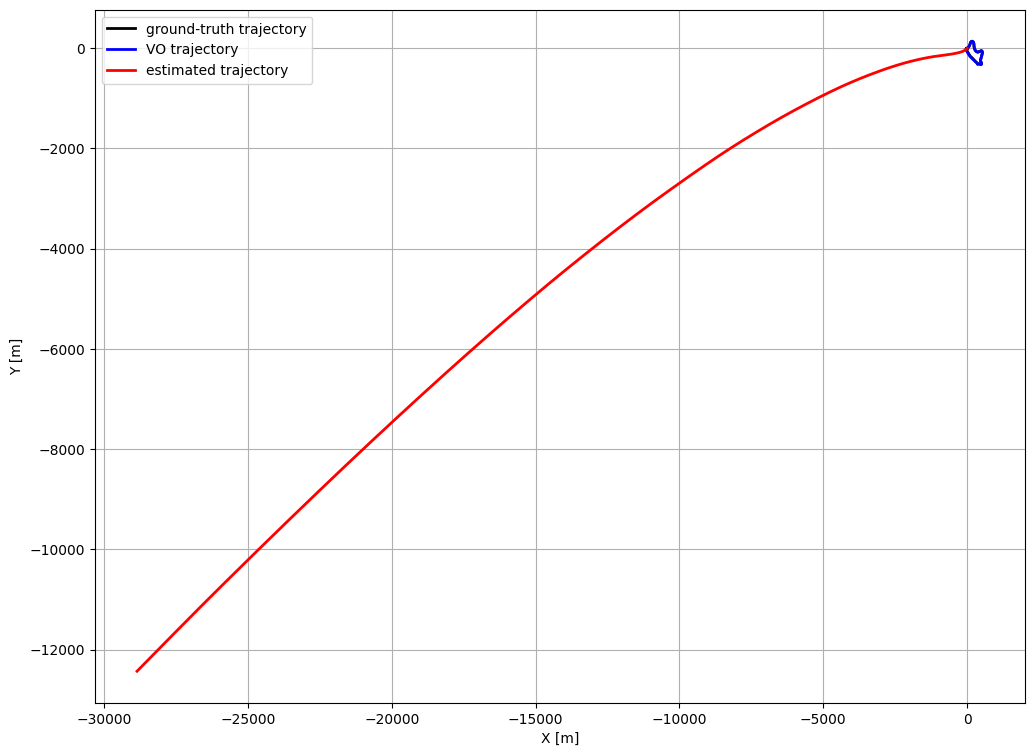

In [8]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.CKF,
    noise_type=noise_type
)

ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
)
error_ckf= ckf1_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type
)

# Velocity Model

## EKF

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 48255.74it/s]


----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 34.087 m
Root Mean Squared Error: 42.365 m
Maximum Error: 83.961 m
-----------------------------------------------



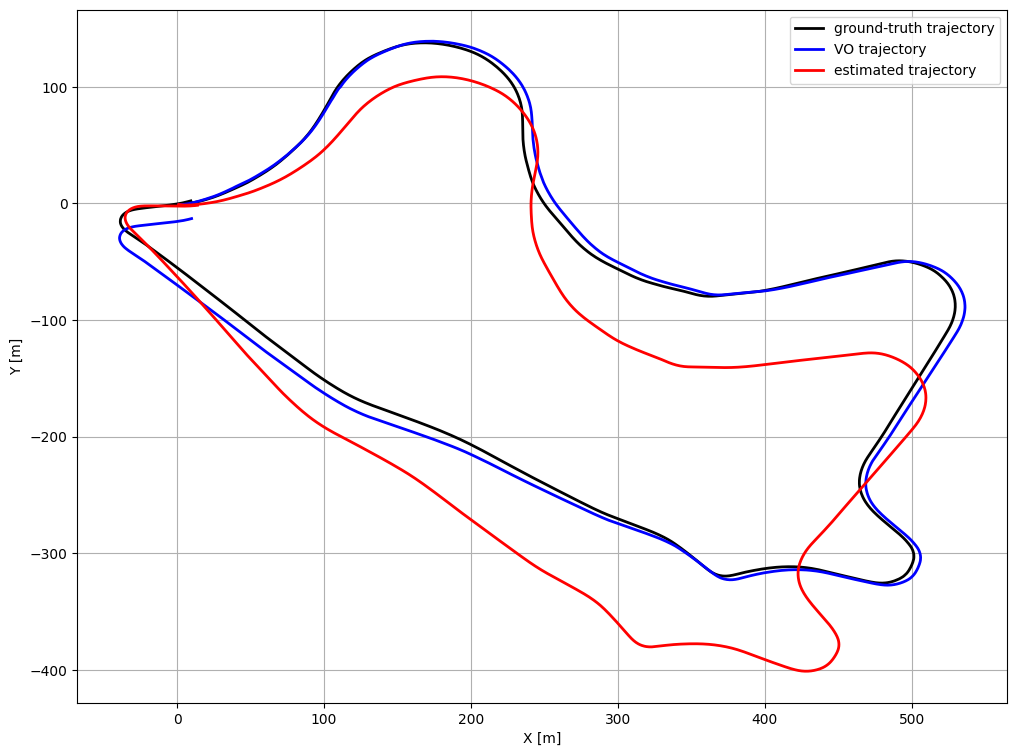

In [9]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF, 
    noise_type=noise_type)

ekf3_0 = ExtendedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3
)

ekf_error3 = ekf3_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type
)

## UKF

[UKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 22577.96it/s]


----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 182.604 m
Root Mean Squared Error: 218.33 m
Maximum Error: 413.611 m
-----------------------------------------------



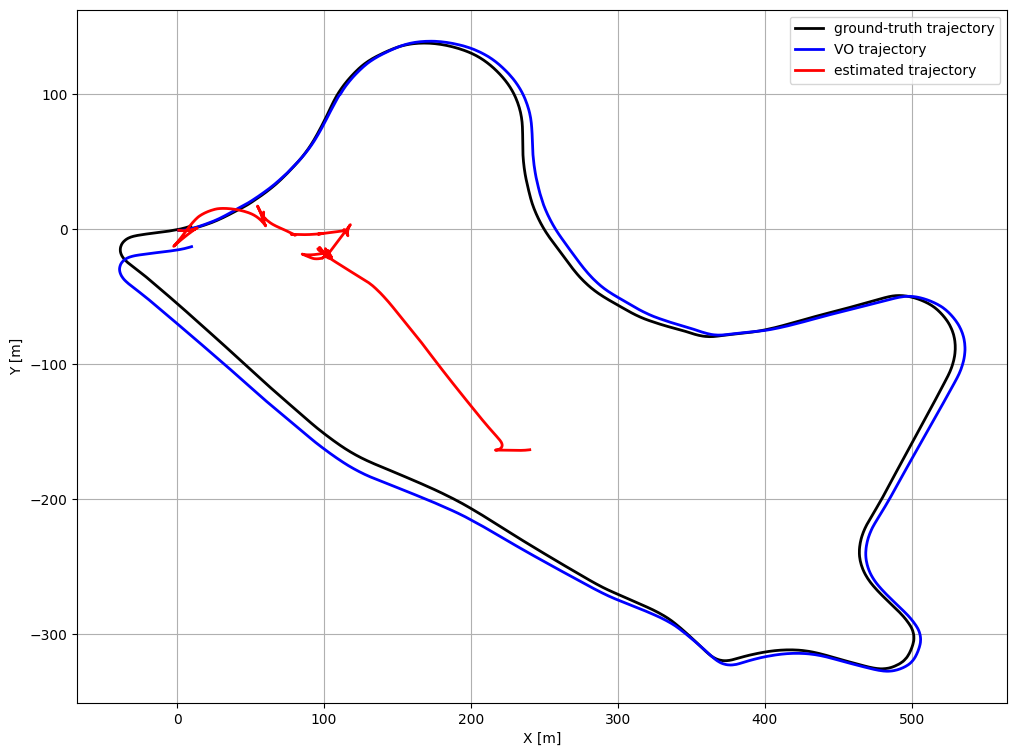

In [10]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type)

alpha_setup3_0 = 1.0
beta_setup3_0 = 2.0
kappa_setup3_0 = 0.0

ukf3_0 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3
)

ukf_error3 = ukf3_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type
)

## PF

[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 691.64it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 205.079 m
Root Mean Squared Error: 259.888 m
Maximum Error: 528.159 m
----------------------------------------------



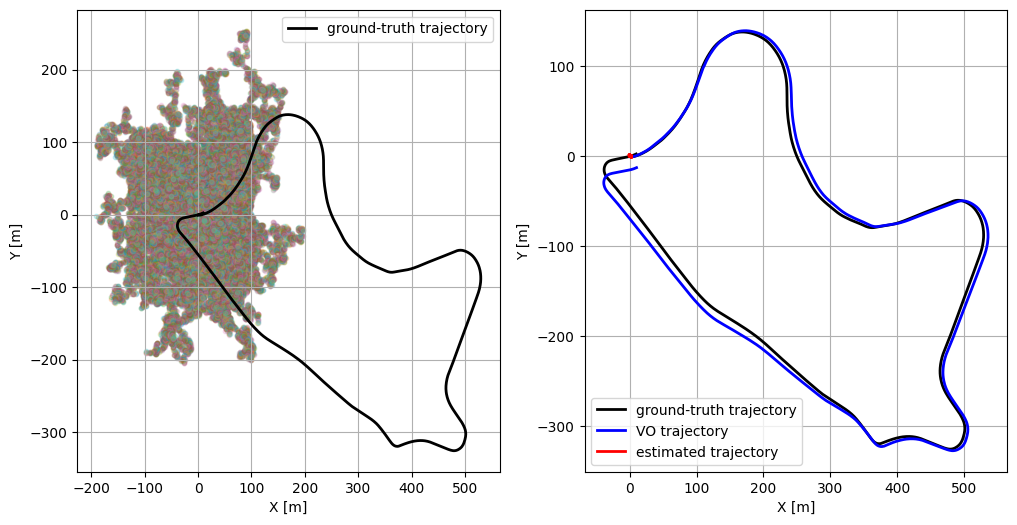

In [11]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)

n_samples_setup3_0 = 1024
importance_resampling=True
resampling_algorithm_setup3_0 = ResamplingAlgorithms.STRATIFIED

pf3_0 = ParticleFilter(N=n_samples_setup3_0, 
                        x_dim=x_setup3.shape[0], 
                        H=H_setup3.copy(), 
                        q=q3,
                        r_vo=r_vo3,
                        r_gps=r_gps3,
                        setup=SetupEnum.SETUP_3,
                        resampling_algorithm=resampling_algorithm_setup3_0)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

pf_error3 = pf3_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type,
    importance_resampling=importance_resampling
)

## EnKF

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 641.78it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 204.11 m
Root Mean Squared Error: 258.648 m
Maximum Error: 526.398 m
------------------------------------------------



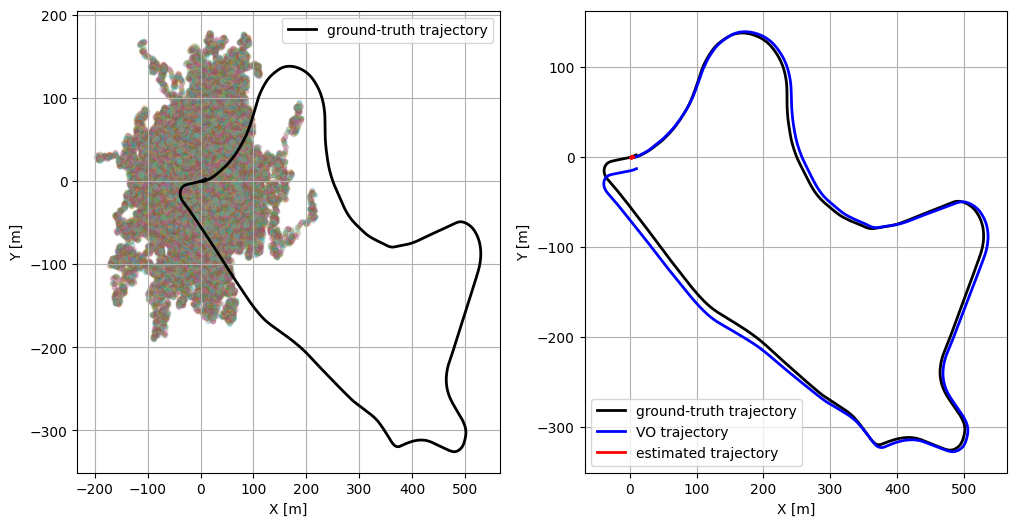

In [12]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)

n_ensemble_setup3_0 = 2048

enkf3_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup3_0, 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3
)

error_enkf3 = enkf3_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type
)

## CKF

[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 22920.25it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 177.696 m
Root Mean Squared Error: 218.665 m
Maximum Error: 517.073 m
-----------------------------------------------



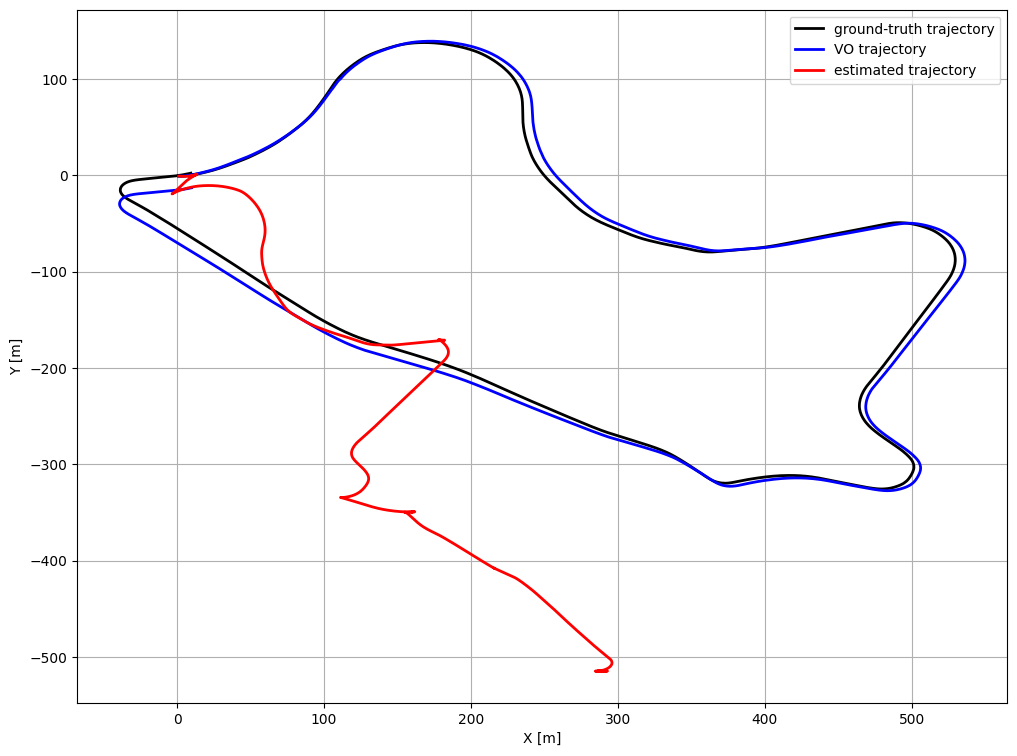

In [13]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)

ckf3_0 = CubatureKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
)
ckf_error3 = ckf3_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=measurement_type
)

# Conclusion

In this notebook, all filters are applied to the sequenece number 09 KITTI raw dataset only using IMU data. 
The experiment revieals that EKF has the best estimation among the other filers.

Moreover, the velocity motion model provides better estimation result than that of the Basic of Kinematics motion model.

The reason why the other filters were incapable to estimate the state is derived from their characteristics.

## Assumptions

In this experiment, the EKF estimates the state solely using the motion model based on its implementation, meaning it does not rely on the state error covariance matrix. In contrast, other filters like the UKF and CKF utilize the state error covariance matrix to provide state estimates, particularly when computing sigma points. Statistical methods such as PF and EnKF initialize their samples using a Gaussian distribution, resulting in an inherent error between the state and samples. Additionally, for PF, if there is no measurement update step, the resampling process does not occur, leading to uncorrected sample values and poor estimation. Similarly, the EnKF uses sample data points, known as ensembles, and computes the state estimate by taking the mean value of the ensembles. Without a measurement update step, the initialized ensembles, which already contain random noise, are never corrected. This causes the ensembles to spread around the initial point, resulting in poor estimation.

In summary, a filter driven solely by the motion model without any consideration of the uncertainty of the state estimate will provide the best results.

https://www.notion.so/Unscented-Kalman-Filter-ea1680e5b3044ca897d29de974f87ad9?pvs=4